# 04 — DBSCAN Anomaly Detection
Use DBSCAN to find dense customer clusters and flag sparse, isolated
points as "Noise" — our proxy for anomalous / potentially fraudulent
behavior (e.g. spending far outside what's typical for that income
level, or age/income/spend combinations that don't resemble any dense
group).

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from src.preprocessing import get_feature_matrix, FEATURE_COLUMNS
from src.clustering import k_distance_plot_data, fit_dbscan, label_personas

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
df = pd.read_csv("../data/processed/mall_customers_with_clusters.csv")
scaler = joblib.load("../models/scaler.joblib")

X = get_feature_matrix(df)
X_scaled = scaler.transform(X)

## Choose `eps` using a k-distance plot
Look for the 'knee' — the point where distance sharply increases.
That distance value is a good starting point for `eps`.

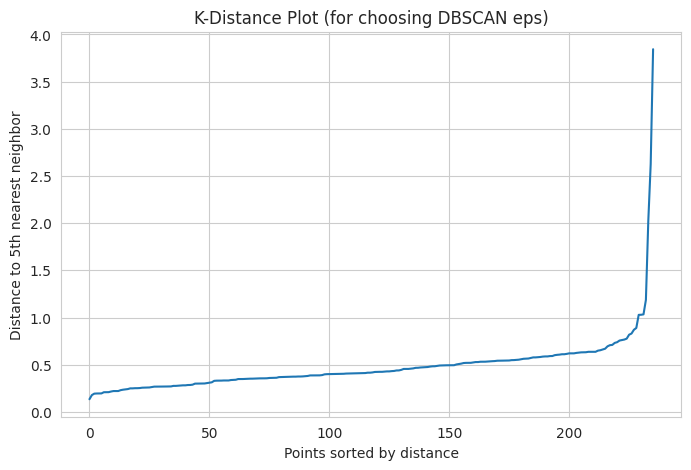

Try eps values around where the curve visibly bends upward.


In [3]:
min_samples = 5
k_distances = k_distance_plot_data(X_scaled, min_samples=min_samples)

plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {min_samples}th nearest neighbor")
plt.title("K-Distance Plot (for choosing DBSCAN eps)")
plt.savefig("../reports/figures/04_kdistance_plot.png", dpi=120)
plt.show()

print("Try eps values around where the curve visibly bends upward.")

## Fit DBSCAN
Tune `eps` based on the knee above. Starting guess included — adjust
and re-run this cell until the noise points look like genuine
outliers rather than a large chunk of normal customers.

In [4]:
eps = 0.6          # <-- tune this based on the k-distance plot
min_samples = 5    # <-- and this: higher = stricter about what counts as "dense"

dbscan_model, dbscan_labels = fit_dbscan(X_scaled, eps=eps, min_samples=min_samples)
df["Cluster_DBSCAN"] = dbscan_labels

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"Clusters found: {n_clusters}")
print(f"Noise points (potential anomalies): {n_noise} ({n_noise/len(df):.1%} of customers)")

Clusters found: 4
Noise points (potential anomalies): 16 (6.8% of customers)


## Visualize: dense clusters vs noise/anomalies

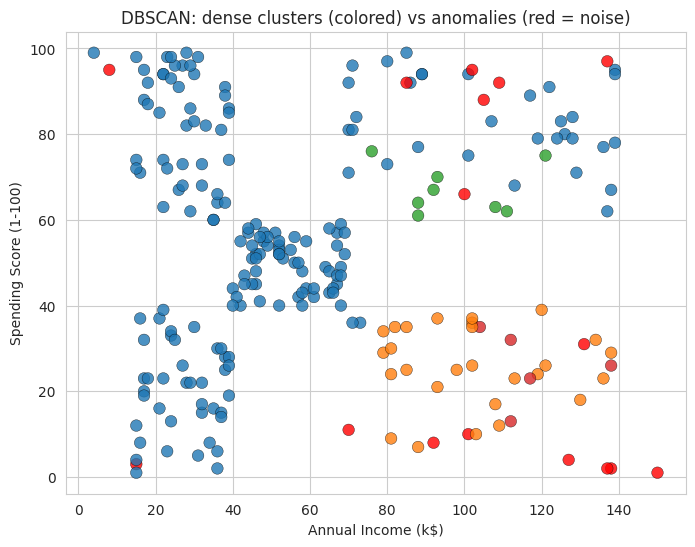

In [5]:
plt.figure(figsize=(8, 6))
palette = sns.color_palette("tab10", n_colors=max(dbscan_labels) + 2)
colors = ["red" if l == -1 else palette[l] for l in dbscan_labels]

plt.scatter(
    df["Annual Income (k$)"], df["Spending Score (1-100)"],
    c=colors, s=70, alpha=0.8, edgecolor="k", linewidth=0.3
)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("DBSCAN: dense clusters (colored) vs anomalies (red = noise)")
plt.savefig("../reports/figures/04_dbscan_anomalies.png", dpi=120)
plt.show()

## Inspect the flagged anomalies

In [6]:
anomalies_df = df[df["Cluster_DBSCAN"] == -1][["CustomerID", "Age", "Annual Income (k$)", "Spending Score (1-100)", "Gender"]]
print(f"{len(anomalies_df)} customers flagged as anomalies:")
anomalies_df

16 customers flagged as anomalies:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender
8,9,39,101,10,Male
45,46,22,15,3,Female
46,47,29,100,66,Male
67,68,43,105,88,Male
68,69,41,109,92,Male
79,80,35,92,8,Male
96,97,42,127,4,Female
112,113,41,85,92,Male
125,126,19,137,97,Male
129,130,47,70,11,Female


## Notes
- If DBSCAN flags too many points as noise, `eps` is too small — increase it.
- If DBSCAN finds only 1 giant cluster and 0 noise, `eps` is too large — decrease it.
- On this dataset the flagged points should roughly line up with the
  clear outliers visible in the very first scatter plot from notebook 01
  (very high spend at very low income, or the reverse, or extreme ages).
- In a real fraud-detection setting you'd validate these flags against
  known fraud labels (precision/recall) rather than eyeballing a scatter
  plot — this notebook is a starting point for that pipeline, not a
  finished fraud model.

In [7]:
df.to_csv("../data/processed/mall_customers_with_clusters.csv", index=False)
joblib.dump(dbscan_model, "../models/dbscan_model.joblib")
print("Updated processed data and saved dbscan_model.joblib")

Updated processed data and saved dbscan_model.joblib
